# Constrained Expected Improvement

This section demonstrates the implementation of constrained BO with constrained Expected Improvement (EI) as the acqusition function. In this formulation, the conventional EI acquisitoin function introduced in the previous section is maximized while a surrogate model for the constraint function is used to impose the constraint directly during the optimization. The auxilliary optimization problem formulation can be written as

$$
\begin{align*}
    \max_{x \in \Omega} \quad & EI(x) \\
    \text{subject to} \quad & \hat{g}_j(x) \leq 0, \quad j = 1, \dots, m\\
    & \hat{h}_k(x) = 0, \quad k = 1, \dots, n
\end{align*}
$$

where $\hat{f}(x)$ is the surrogate model prediction, $\hat{g}_j(x)$ is the surrogate model for the $j^{th}$ inequality constraint,  $\hat{h}_k(x)$ is the surrogate model for the $k^{th}$ equality constraint, $m$ is the number of inequality constraints and $n$ is the number of equality constraints. In the example of the constrained Branin function, there is only one inequality constraint and no equality constraints. The constrained expected improvement method selects the next infill point in the process by maximizing the expected improvement subject to the prediction of the surrogate models of the constraints of the problem. This formulation balances exploitation and exploration while imposing the constraints of the optimization problem. The EI is defined in a [previous section](https://computationaldesignlab.github.io/surrogate-methods/bo/ei.html).

Below code imports required packages, defines modified branin function and constraint function:

In [28]:
import numpy as np
import torch
from pyDOE3 import lhs
import matplotlib.pyplot as plt
from scipy.stats import norm as normal
from scimlstudio.models import SingleOutputGP
from scimlstudio.utils import Standardize, Normalize
from gpytorch.mlls import ExactMarginalLogLikelihood

from pymoo.core.problem import Problem
from pymoo.algorithms.soo.nonconvex.de import DE
from pymoo.optimize import minimize
from pymoo.config import Config
Config.warnings['not_compiled'] = False

# Defining the device and data types
args = {
    "device": torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    "dtype": torch.float64
}

def modified_branin(x: np.ndarray) -> np.ndarray:
    """
        Function for computing modified branin function value at given input points
    """

    x = np.atleast_2d(x)

    x1 = x[:,0]
    x2 = x[:,1]

    a = 1.
    b = 5.1 / (4.*np.pi**2)
    c = 5. / np.pi
    r = 6.
    s = 10.
    t = 1. / (8.*np.pi)

    y = a * (x2 - b*x1**2 + c*x1 - r)**2 + s*(1-t)*np.cos(x1) + s + 5*x1

    return np.expand_dims(y,-1)

def constraint(x):
    """
        Function for computing constraint function value at given input points
    """

    x = np.atleast_2d(x)

    x1 = x[:,0]
    x2 = x[:,1]

    g = -x1*x2 + 30
    
    return np.expand_dims(g,-1)

# Bounds
lb = np.array([-5, 0])
ub = np.array([10, 15])

The block of code below defines the pymoo class for the auxiliary optimization of the constrained expected improvement method. This class calculates the value of EI as the objective function and stores it in the `out` dictionary in the `_evaluate` method of the class. Since this is performing constrained optimization, the `n_constr` argument in `super().__init__` is specified to reflect the number of constraints. The `out` dictionary in the `_evaluate` method of the class also stores the constraint values through `out["G"]`. 

After the class is defined, the `differential evolution` class is initialized. The initialization of this class is identical to the initialization in previous BO sections. 

In [29]:
class ConstrainedExpectedImprovement(Problem):

    def __init__(self, gp_obj, gp_const, lb: np.ndarray, ub: np.ndarray, fbest: float):
        """
            Class for defining auxiliary optimization problem that uses
            expected improvment as the acquisition function and imposes constraints directly.
            The constraint is imposed using the surrogate model of the constraint function. 
        """

        # initialize parent class
        super().__init__(n_var=lb.shape[0], n_obj=1, n_constr=1, xl=lb, xu=ub)

        # store variables
        self.gp_obj = gp_obj
        self.gp_const = gp_const
        self.fbest = fbest

    def _evaluate(self, x, out, *args, **kwargs):

        # convert to torch tensor
        x = torch.from_numpy(x).to(self.gp_obj.x_train)

        # get mean prediction and std in prediction
        y_mean, y_std = self.gp_obj.predict(x)

        # get constraint prediction
        g_mean, _ = self.gp_const.predict(x)

        # numerator of Z
        numerator = self.fbest - y_mean.numpy(force=True)

        # denominator of Z
        denominator = y_std.numpy(force=True)

        # std variable
        z = numerator / denominator

        # compute ei
        ei = numerator * normal.cdf(z) + denominator * normal.pdf(z)

        out["F"] = - ei # negating since pymoo minimizes
        out["G"] = g_mean.numpy(force=True) # constraint value should be negative for the point to be feasible

# optimization algorithm
algorithm = DE(pop_size=15*lb.shape[0], F=0.9, CR=0.8, seed=1)

## BO Loop

The block of code below implements the BO loop for constrained expected improvement with probability of feasibility. The number of initial samples is 4 with the maximum function evaluations set to 30. This means that there will be 26 iterations of the loop. Latin Hypercube sampling is used to generate the initial samples. Gaussian process (GP) models are used to approximate the modified Branin function and the constraint function of the problem. This is because GP models provide both a mean prediction and the uncertainty in the model prediction, which is necessary for calculating EI and PF. 

In [30]:
# variables
num_init = 4
max_evals = 30
num_evals = 0

# initial training data
x_train = lhs(lb.shape[0], samples=num_init, criterion='cm', iterations=100, seed=1)
x_train = lb + (ub - lb) * x_train
y_train = modified_branin(x_train)
g_train = constraint(x_train)

# increment evals
num_evals += num_init

ybest = np.min(y_train[g_train < 0])
idx_best = np.where(y_train == ybest)[0][0]
fbest = [ybest]
xbest = [x_train[idx_best]]
gbest = [g_train[idx_best]]

print("Current best before loop:")
print("x: {}".format(xbest[-1]))
print("f: {}".format(fbest[-1]))
print("g: {}".format(gbest[-1]))

print("\nConstrained EI Loop:")

# loop
while num_evals < max_evals:

    print(f"\nIteration: {num_evals-num_init+1}")

    # training the objective function GP model
    gp_obj = SingleOutputGP(
        x_train=torch.from_numpy(x_train).to(**args),
        y_train=torch.from_numpy(y_train).to(**args),
        output_transform=Standardize,
        input_transform=Normalize,
    )
    mll_obj = ExactMarginalLogLikelihood(gp_obj.likelihood, gp_obj) # marginal log likelihood
    optimizer = torch.optim.Adam(gp_obj.parameters(), lr=0.01) # optimizer
    gp_obj.fit(training_iterations=1000, mll=mll_obj, optimizer=optimizer)

    # training the constraint function GP model
    gp_const = SingleOutputGP(
        x_train=torch.from_numpy(x_train).to(**args),
        y_train=torch.from_numpy(g_train).to(**args),
        output_transform=Standardize,
        input_transform=Normalize,
    )
    mll_const = ExactMarginalLogLikelihood(gp_const.likelihood, gp_const) # marginal log likelihood
    optimizer = torch.optim.Adam(gp_const.parameters(), lr=0.01) # optimizer
    gp_const.fit(training_iterations=1000, mll=mll_const, optimizer=optimizer)

    # Find the minimum of surrogate model
    result = minimize(ConstrainedExpectedImprovement(gp_obj, gp_const, lb, ub, fbest[-1]), algorithm, verbose=False)

    # Computing true function value at infill point
    y_infill = modified_branin(result.X)
    g_infill = constraint(result.X)

    print("New point (based on constrained EI):")
    print("x: {}".format(result.X))
    print("f: {}".format(y_infill.item()))
    print("g: {}".format(g_infill.item()))

    # Appending the the new point to the current data set
    x_train = np.vstack(( x_train, result.X.reshape(1,-1) ))
    y_train = np.vstack((y_train, y_infill))
    g_train = np.vstack((g_train, g_infill))

    # increment evals
    num_evals += 1

    # Find current best point
    ybest = np.min(y_train[g_train < 0])
    idx_best = np.where(y_train == ybest)[0][0]
    fbest.append(ybest)
    xbest.append(x_train[idx_best])
    gbest.append(g_train[idx_best])
    
    print("Current best:")
    print("x: {}".format(xbest[-1]))
    print("f: {}".format(fbest[-1]))
    print("g: {}".format(gbest[-1]))

fbest = np.array(fbest)
xbest = np.array(xbest)
gbest = np.array(gbest)

Current best before loop:
x: [8.125 9.375]
f: 108.5539005871506
g: [-46.171875]

Constrained EI Loop:

Iteration: 1
New point (based on constrained EI):
x: [7.27693247 4.59887973]
f: 62.77654730704693
g: -3.465737248869459
Current best:
x: [7.27693247 4.59887973]
f: 62.77654730704693
g: [-3.46573725]

Iteration: 2
New point (based on constrained EI):
x: [10. 15.]
f: 195.8721908793957
g: -119.99999999999983
Current best:
x: [7.27693247 4.59887973]
f: 62.77654730704693
g: [-3.46573725]

Iteration: 3
New point (based on constrained EI):
x: [6.64311343 5.02578306]
f: 67.39360917487127
g: -3.3868469356962336
Current best:
x: [7.27693247 4.59887973]
f: 62.77654730704693
g: [-3.46573725]

Iteration: 4
New point (based on constrained EI):
x: [10.          3.17585013]
f: 51.973032832301925
g: -1.758501257016352
Current best:
x: [10.          3.17585013]
f: 51.973032832301925
g: [-1.75850126]

Iteration: 5
New point (based on constrained EI):
x: [9.61921125 3.0880312 ]
f: 48.87213246499081
g: 0.

> __*NOTE*__: The minimum obtained at the end of process is minimum feasible $y$ observed in the training data and **not** minimum of the surrogate model.

Below block of code plots the evolution of the best objective function, best design point and constraint values of the sampling process through constrained expected improvement with probability of feasibility.

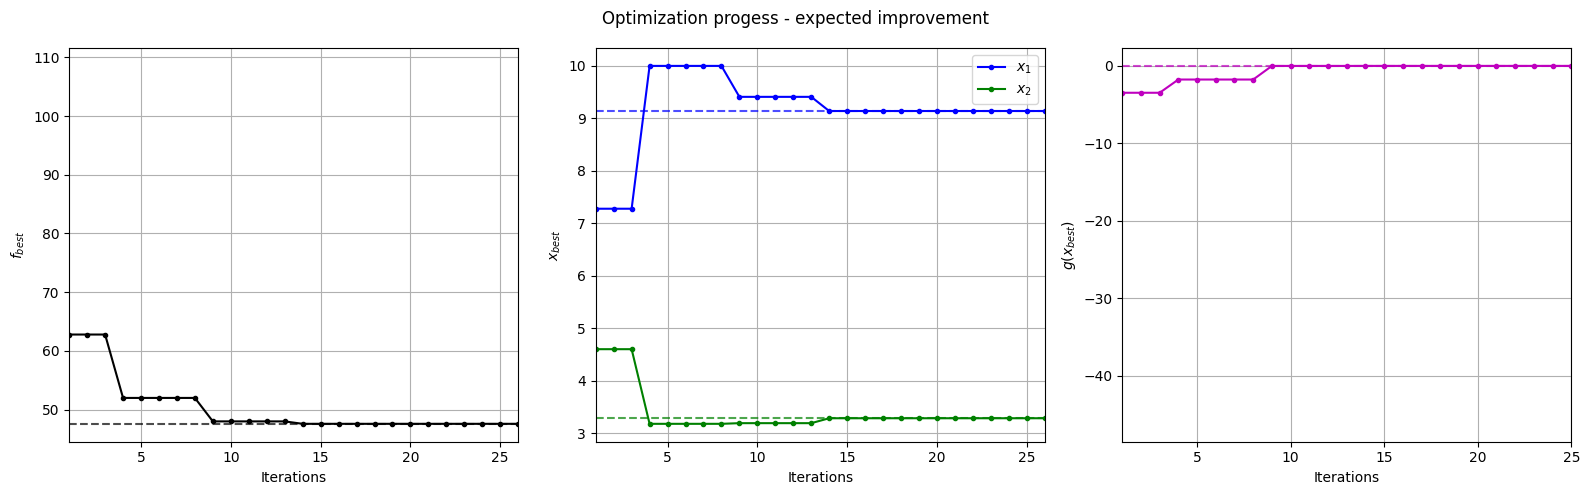

In [31]:
fig, ax = plt.subplots(1, 3, figsize=(16, 5))

ax[0].plot(fbest, ".k-")
ax[0].set_xlabel("Iterations")
ax[0].set_ylabel("$f_{best}$")
ax[0].axhline(y=modified_branin(np.array([[9.143, 3.281]])), c="k", linestyle="--", alpha=0.7)
ax[0].set_xlim(left=1, right=fbest.shape[0]-1)
ax[0].grid()

ax[1].plot(xbest[:,0], ".b-", label="$x_1$")
ax[1].plot(xbest[:,1], ".g-", label="$x_2$")
ax[1].axhline(y=9.143, c="b", linestyle="--", alpha=0.7)
ax[1].axhline(y=3.281, c="g", linestyle="--", alpha=0.7)
ax[1].set_xlim(left=1, right=xbest.shape[0]-1)
ax[1].set_ylabel("$x_{best}$")
ax[1].set_xlabel("Iterations")
ax[1].legend()
ax[1].grid()

ax[2].plot(gbest, ".m-")
ax[2].set_xlabel("Iterations")
ax[2].set_ylabel("$g(x_{best})$")
ax[2].axhline(y=0, c="m", linestyle="--", alpha=0.7)
ax[2].set_xlim(left=1, right=g_train[num_init:].shape[0]-1)
ax[2].grid()

_ = plt.suptitle("Optimization progess - expected improvement")
plt.tight_layout()

Below block of code plots the infill points along with the contours of the true objective and constraint functions.

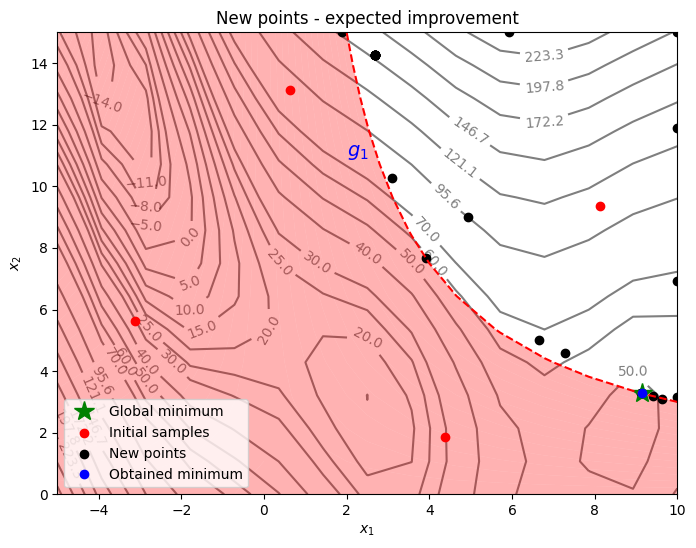

In [32]:
num_pts_per_dim = 15
x1 = np.linspace(lb[0], ub[0], num_pts_per_dim)
x2 = np.linspace(lb[1], ub[1], num_pts_per_dim)
X1, X2 = np.meshgrid(x1, x2)

x = np.hstack(( X1.reshape(-1,1), X2.reshape(-1,1) ))

Z = modified_branin(x).reshape(num_pts_per_dim, num_pts_per_dim)
G = constraint(x).reshape(num_pts_per_dim, num_pts_per_dim)

# Level
levels = np.linspace(-17, -5, 5)
levels = np.concatenate((levels, np.linspace(0, 30, 7)))
levels = np.concatenate((levels, np.linspace(40, 60, 3)))
levels = np.concatenate((levels, np.linspace(70, 300, 10)))

fig, ax = plt.subplots(figsize=(8,6))

# Contours and global opt
CS=ax.contour(X1, X2, Z, levels=levels, colors='k', linestyles='solid', alpha=0.5, zorder=-10)
ax.clabel(CS, inline=1)
ax.plot(9.143, 3.281, 'g*', markersize=15, label="Global minimum")

ax.contour(X1, X2, G, levels=[0], colors='r', linestyles='dashed')
ax.contourf(X1, X2, G, levels=np.linspace(0,G.max()), colors="red", alpha=0.3, antialiased = True)
ax.annotate('$g_1$', xy =(2.0, 11.0), fontsize=14, color='b')

# Pointss
ax.scatter(x_train[0:num_init,0], x_train[0:num_init,1], c="red", label='Initial samples')
ax.scatter(x_train[num_init:,0], x_train[num_init:,1], c="black", label='New points')
ax.plot(xbest[-1][0], xbest[-1][1], 'bo', label="Obtained minimum")

# asthetics
ax.legend(loc="lower left")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
_ = ax.set_title("New points - expected improvement")

From the above plots, it can be seen that expected improvement finds the minimum of modified branin function while balancing exploration and exploitation. The acquisition function adds a few points in the unexplored regions of the feasible space of the optimization problem before finding the global feasible minimum of the problem. 